# Tropical cyclones in Pacific subregions

Annual IBTrACS indicators for 1981–2020. Annual storm counts include a cyclone in every subregion and calendar year in which its track enters the corresponding box; its class is based on the maximum WMO wind observed inside that box and year. The track map and ACE indicator use an exclusive genesis-region assignment.

- Western North Pacific: 0–40°N, 120–180°E
- Central North Pacific: 0–40°N, 180–220°E (180–140°W)
- Western South Pacific: 0–40°S, 135–180°E
- Central South Pacific: 0–40°S, 180–240°E (180–120°W)

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

sys.path.append("../../../../functions")
from data_downloaders import download_ibtracs
from tcs import (
    annual_region_metrics,
    build_storm_metrics,
    plot_genesis_tracks,
    plot_monthly_intensity_distribution,
    plot_pacific_regions_map,
    plot_period_comparison,
    plot_regional_ace,
    plot_regional_annual_counts,
    plot_regional_intensity_counts,
    plot_regional_map_dashboard,
    plot_spatial_track_density,
)


## Load IBTrACS

The national notebook filters the download to `WP`. Here `basin=None` is required because the four subregions span the WP, EP and SP genesis basins. Set `update_data=True` the first time to create the shared all-basin cache.

In [2]:
update_data = True
url = (
    "https://www.ncei.noaa.gov/data/international-best-track-archive-for-"
    "climate-stewardship-ibtracs/v04r01/access/netcdf/"
    "IBTrACS.ALL.v04r01.nc"
)
path_data = Path("../../../../data/tcs")
path_data.mkdir(parents=True, exist_ok=True)
all_basins_file = path_data / "tcs_ALL.nc"

if update_data:
    tcs = download_ibtracs(url, basin=None)
    tcs.to_netcdf(all_basins_file)
else:
    if not all_basins_file.exists():
        raise FileNotFoundError(
            f"{all_basins_file} does not exist. Set update_data=True once."
        )
    tcs = xr.load_dataset(all_basins_file)

tcs

<xarray.Dataset> Size: 119MB
Dimensions:   (storm: 13577, date_time: 360)
Coordinates:
    time      (storm, date_time) datetime64[ns] 39MB ...
    lat       (storm, date_time) float32 20MB ...
    lon       (storm, date_time) float32 20MB ...
Dimensions without coordinates: storm, date_time
Data variables:
    wmo_wind  (storm, date_time) float32 20MB ...
    wmo_pres  (storm, date_time) float32 20MB ...
    name      (storm) |S128 2MB ...
Attributes: (12/49)
    title:                      IBTrACS - International Best Track Archive fo...
    summary:                    The intent of the IBTrACS project is to overc...
    source:                     The original data are tropical cyclone positi...
    Conventions:                ACDD-1.3
    Conventions_note:           Data are nearly CF-1.7 compliant. The sole is...
    product_version:            v04r01
    ...                         ...
    history:                    Sun Aug 16 05:13:38 2026: ncks --no_abc --cnk...
    license:                    These data may be redistributed and used with...
    featureType:                trajectory
    cdm_data_type:              Trajectory
    comment:                    The tracks of TCs generally look like a traje...
    NCO:                        netCDF Operators version 5.0.7 (Homepage = ht...

## Subregions and annual indicators

Longitudes are converted to 0–360°. For annual counts, a cyclone is included in every box it crosses and is classified by its maximum in-box wind during that calendar year. The genesis classification is retained for the track map and ACE. Thresholds are 34 kt for named storms, 64 kt for typhoons/hurricanes/cyclones, and 96 kt for major systems in all four regions. Missing WMO winds are left out rather than inferred.

In [3]:
START_YEAR, END_YEAR = 1981, 2026
YEARS = np.arange(START_YEAR, END_YEAR + 1)

region_key = "pacific"
maps_dir = Path("../../../../outputs/figures") / f"regional_{region_key}"
maps_dir.mkdir(parents=True, exist_ok=True)

REGIONS = {
    "Western North Pacific": dict(
        lat=(0, 40), lon=(120, 180), system="Typhoons", major_threshold=96
    ),
    "Central North Pacific": dict(
        lat=(0, 40), lon=(180, 220), system="Hurricanes", major_threshold=96
    ),
    "Western South Pacific": dict(
        lat=(-40, 0), lon=(135, 180), system="Cyclones", major_threshold=96
    ),
    "Central South Pacific": dict(
        lat=(-40, 0), lon=(180, 240), system="Cyclones", major_threshold=96
    ),
}

storm_metrics = build_storm_metrics(tcs)

regional_metrics = {
    name: annual_region_metrics(
        tcs, storm_metrics, name, bounds, YEARS, START_YEAR, END_YEAR
    )
    for name, bounds in REGIONS.items()
}
# regional_metrics["Western North Pacific"]


## Pacific tropical-cyclone subregions

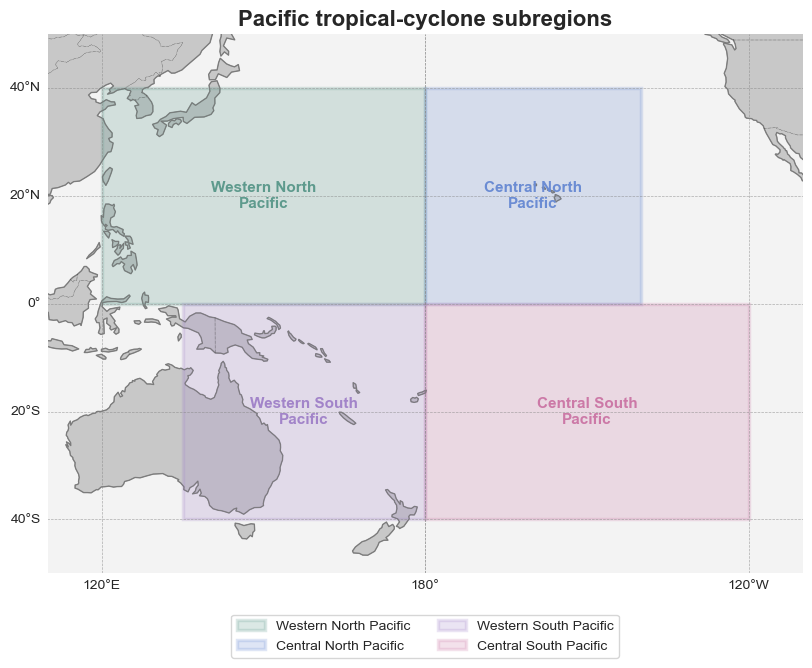

In [4]:
REGION_COLORS = {
    "Western North Pacific": "#5E9A8D",
    "Central North Pacific": "#6B8CD3",
    "Western South Pacific": "#A284C9",
    "Central South Pacific": "#CC79A7",
}

fig, ax = plot_pacific_regions_map(REGIONS, REGION_COLORS)
fig.savefig(
    maps_dir / f"TC_regional_subregions_{region_key}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## Historical cyclone tracks by genesis subregion

Each cyclone is assigned to the subregion containing its first valid IBTrACS position. The complete track is then coloured by that genesis region; cyclones whose genesis falls outside the four boxes are not shown.

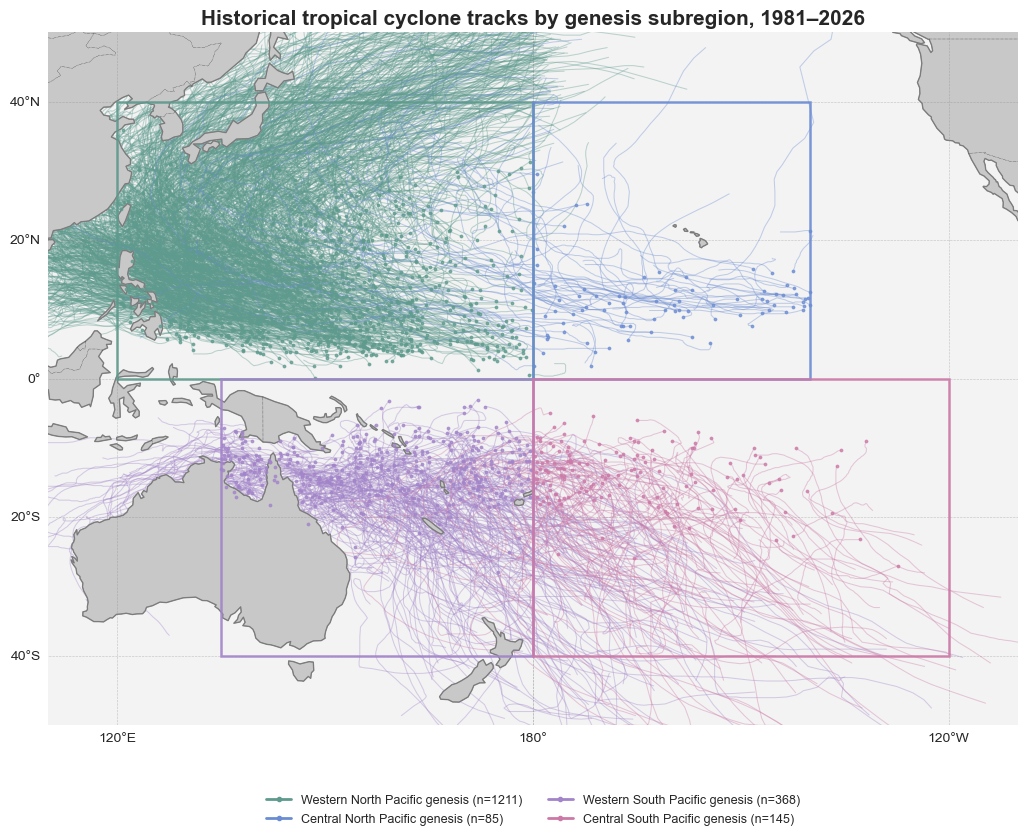

In [5]:
fig, ax = plot_genesis_tracks(
    tcs, REGIONS, REGION_COLORS, START_YEAR, END_YEAR
)
fig.savefig(
    maps_dir / f"TC_regional_genesis_tracks_{region_key}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## Monthly distribution by intensity

Mean annual cyclone genesis by calendar month. Each cyclone is assigned exclusively to its genesis subregion and classified by its maximum WMO wind over the complete track.


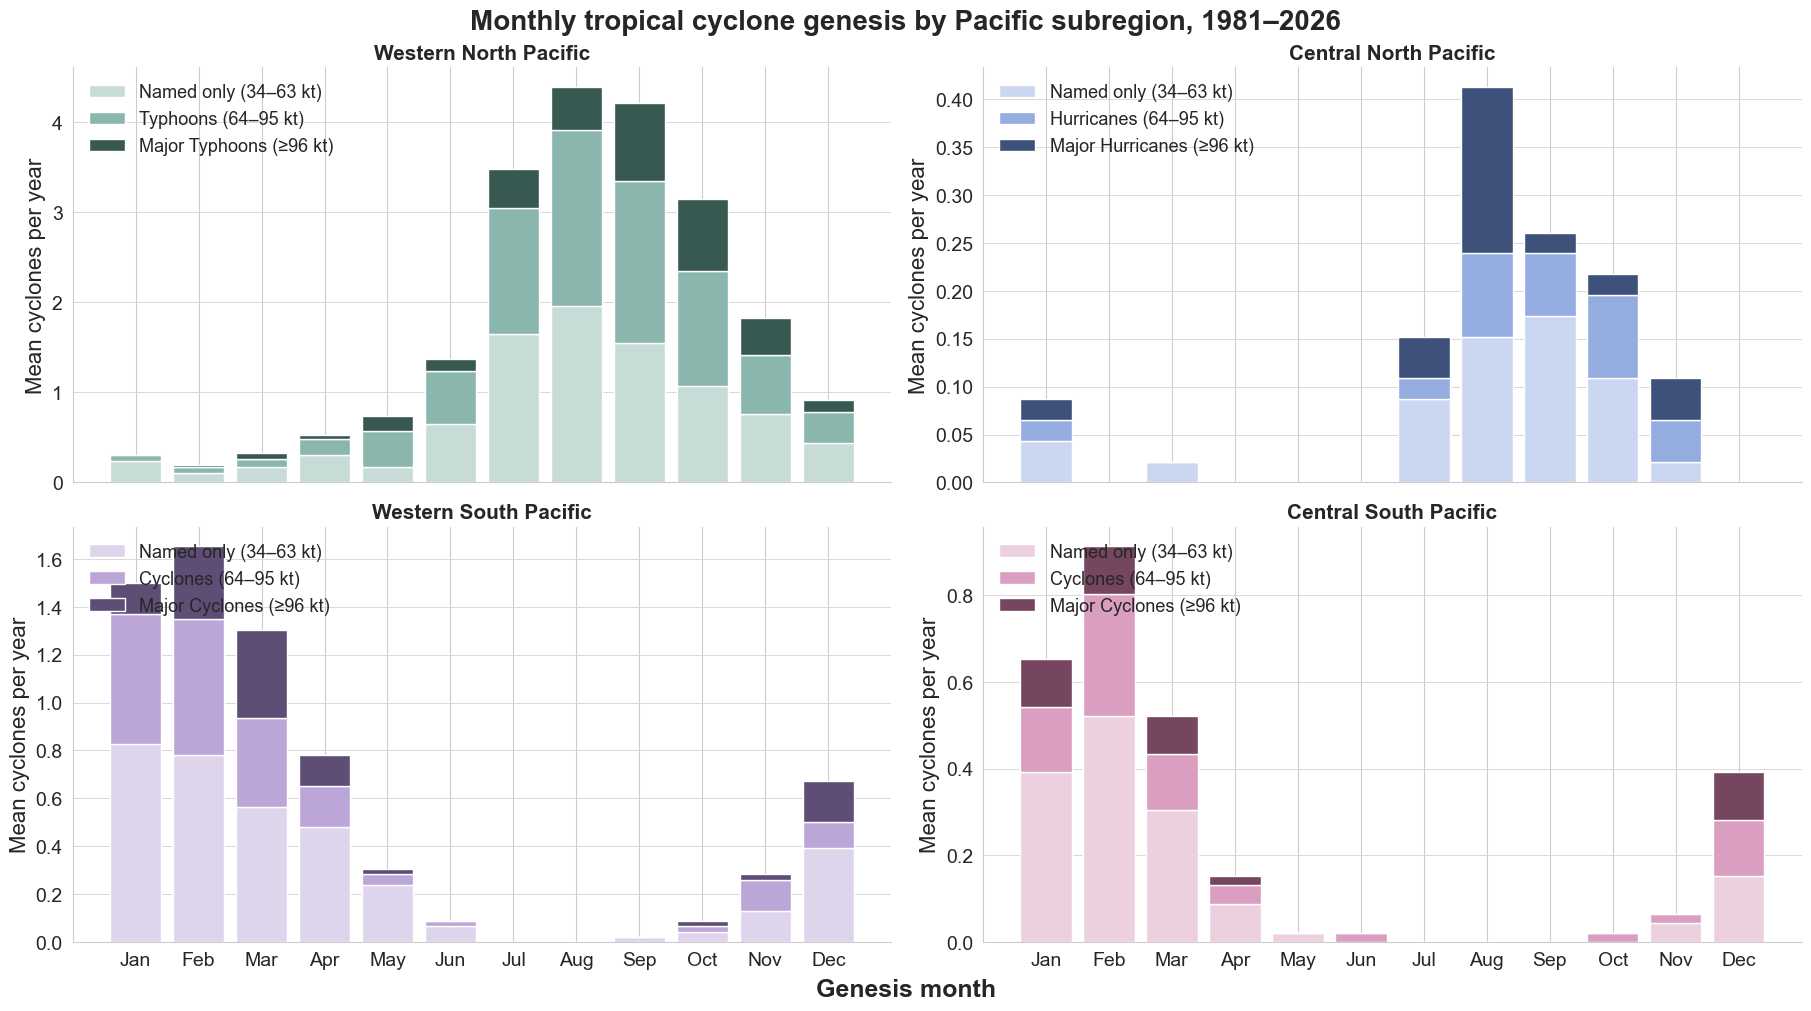

In [6]:
fig, axes = plot_monthly_intensity_distribution(
    storm_metrics, REGIONS, REGION_COLORS, START_YEAR, END_YEAR
)
fig.savefig(
    maps_dir / f"TC_regional_monthly_genesis_{region_key}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## Spatial density of cyclone tracks

Mean annual cyclone passages through 2° grid cells. A cyclone is counted at most once in each cell, avoiding inflated density from repeated observations along the same track.


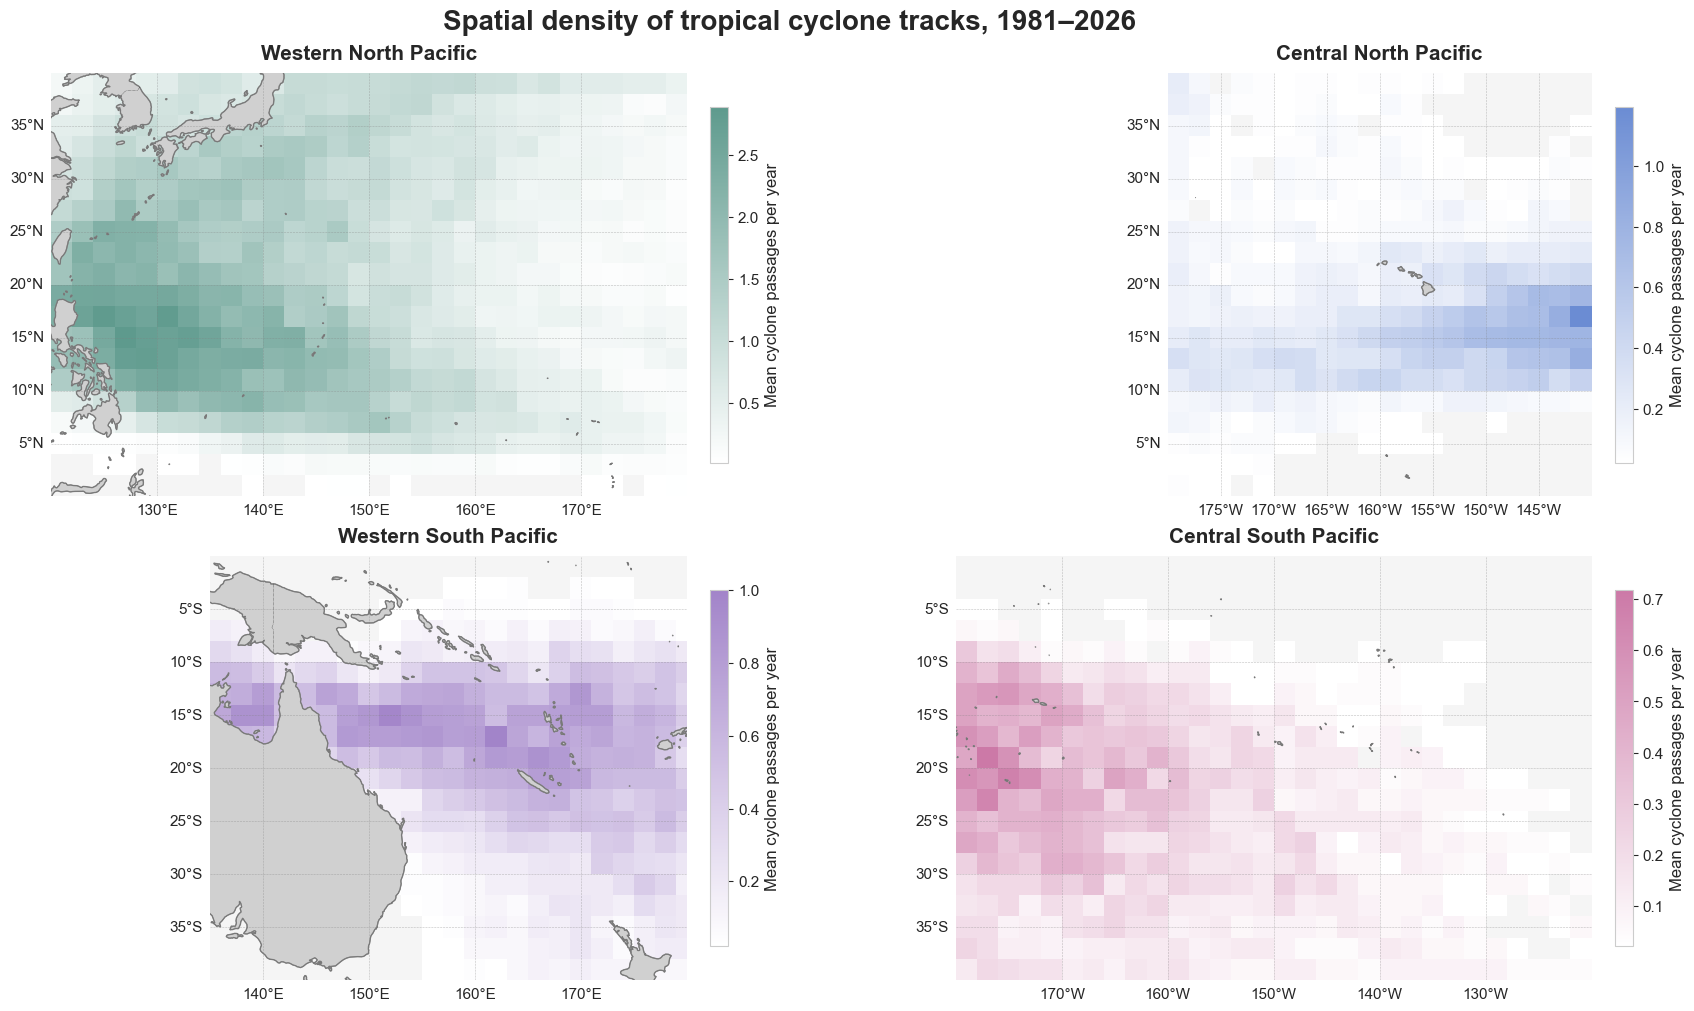

In [7]:
fig, axes = plot_spatial_track_density(
    tcs, REGIONS, REGION_COLORS, START_YEAR, END_YEAR, grid_size=2.0
)
fig.savefig(
    maps_dir / f"TC_regional_track_density_{region_key}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## Comparison between periods

Boxplots compare the distribution of annual named-cyclone counts across four homogeneous 11-year periods. Points show individual years, the central line is the median and the diamond is the mean. Boundary years are included in both adjacent periods.


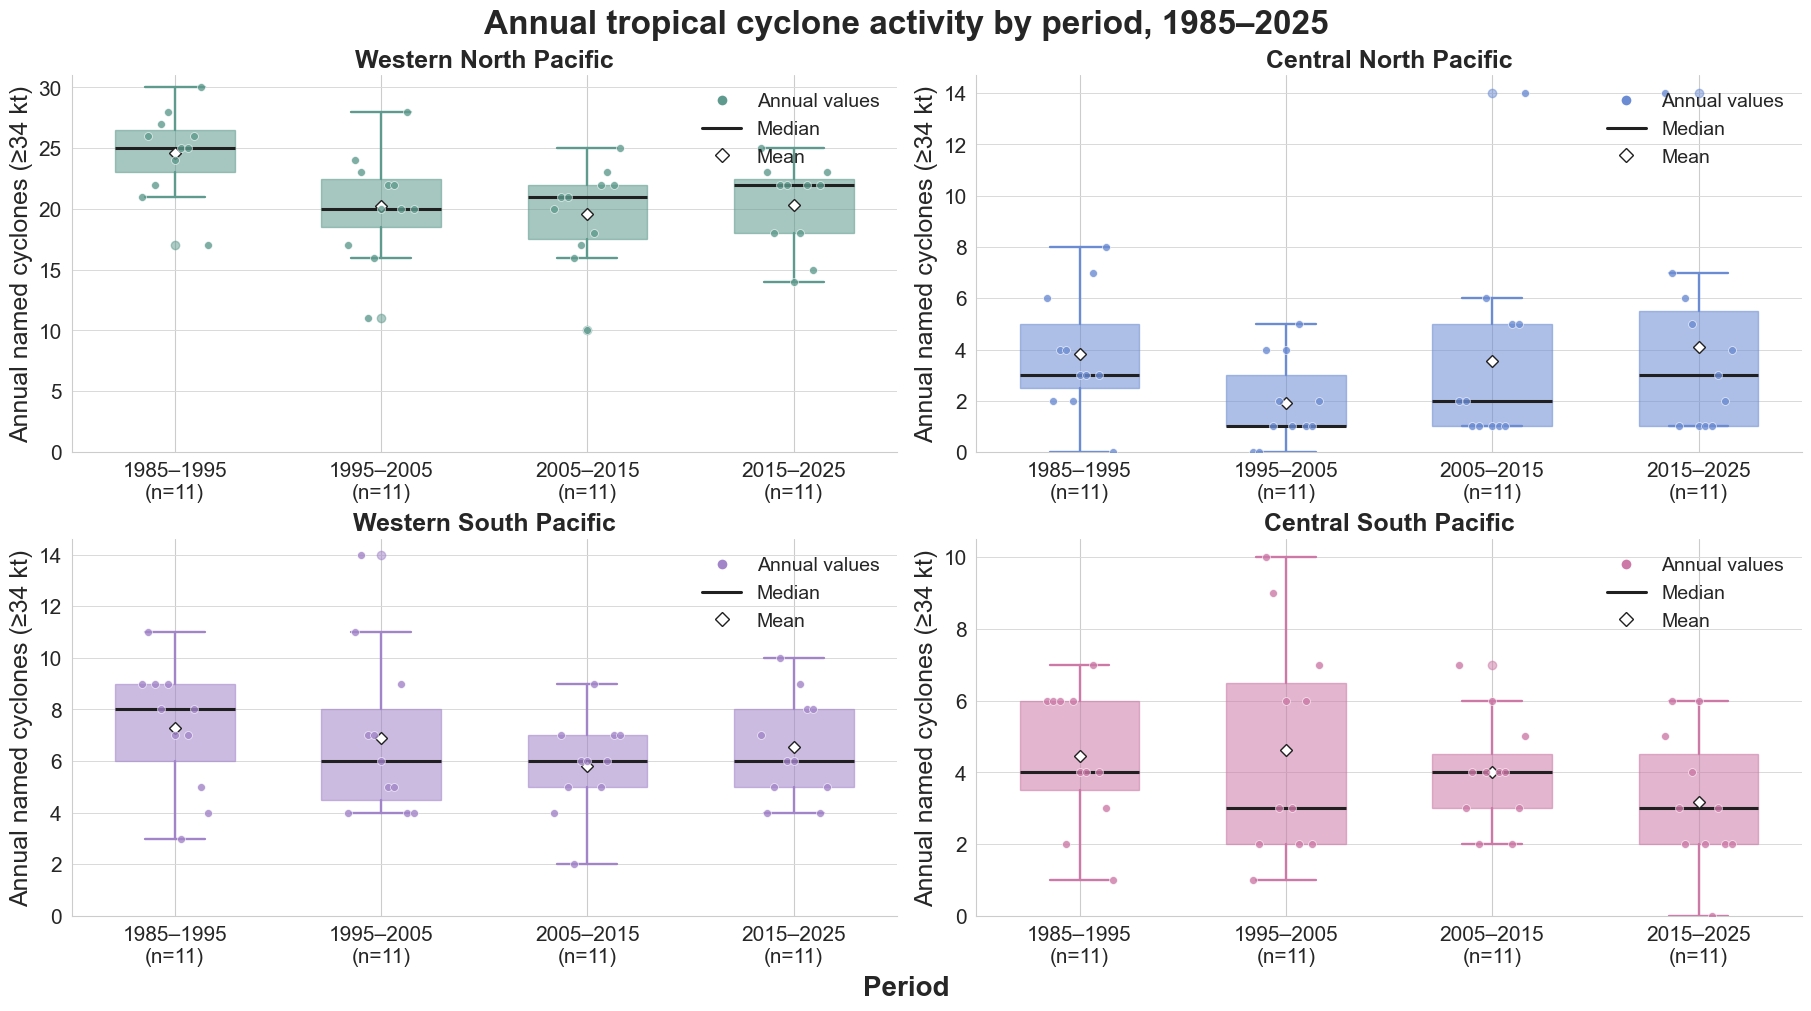

In [8]:
PERIODS = {
    "1985–1995": (1985, 1995),
    "1995–2005": (1995, 2005),
    "2005–2015": (2005, 2015),
    "2015–2025": (2015, 2025),
}

fig, axes = plot_period_comparison(
    regional_metrics, REGION_COLORS, PERIODS, metric="named"
)
fig.savefig(
    maps_dir / f"TC_regional_period_comparison_{region_key}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## Annual storm counts

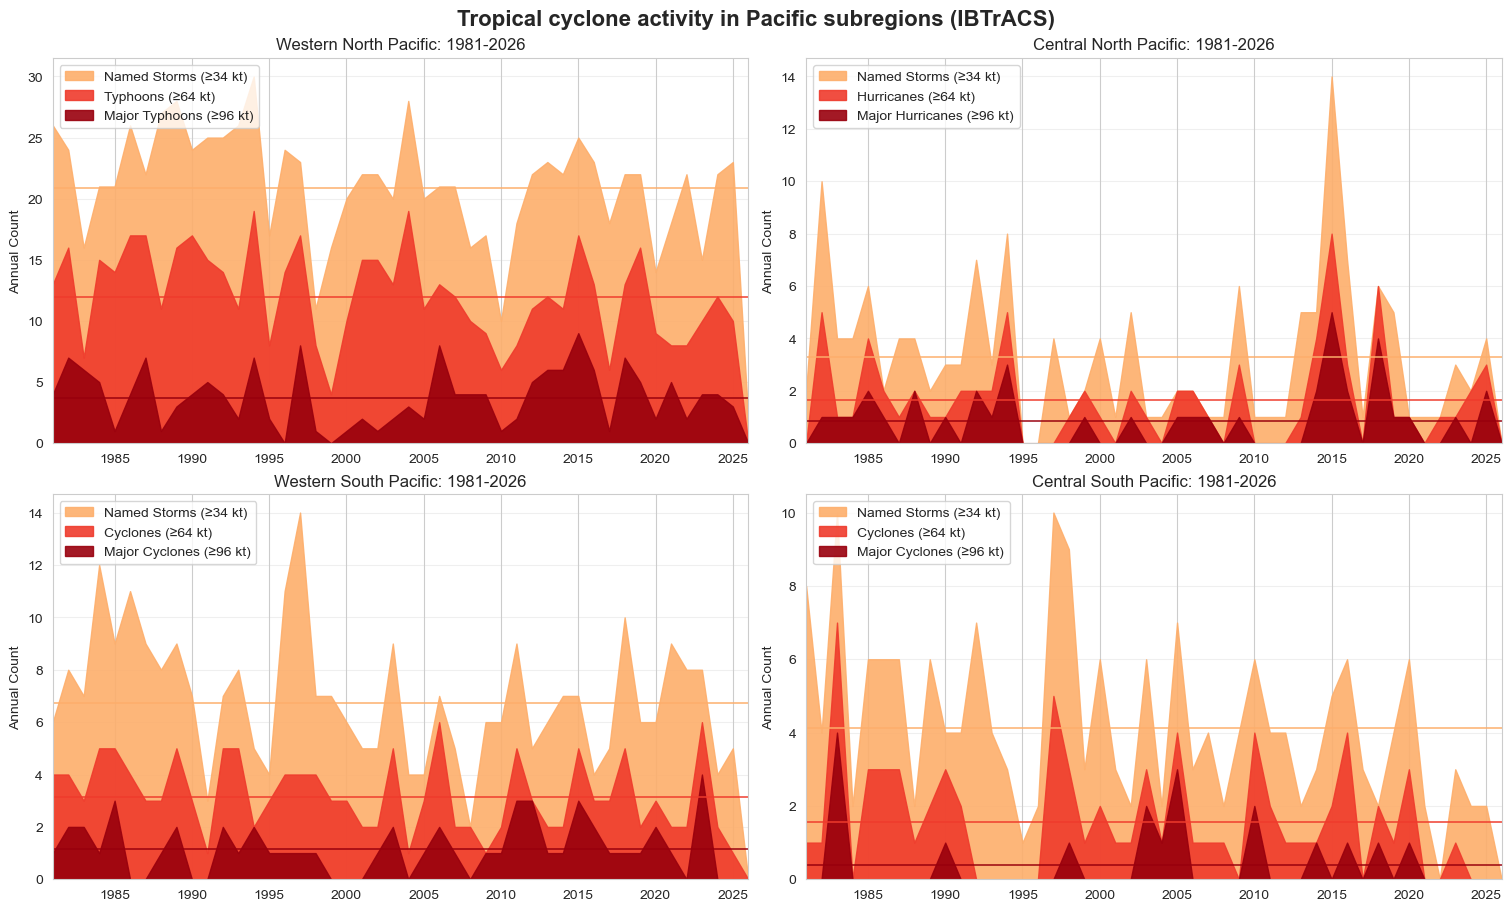

In [9]:
COLORS = {"named": "#fdae6b", "system": "#ef3b2c", "major": "#99000d"}

fig, axes = plot_regional_annual_counts(
    regional_metrics, REGIONS, START_YEAR, END_YEAR, COLORS
)
fig.savefig(
    maps_dir / f"TC_regional_annual_counts_{region_key}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## Annual storm counts — stacked intensity composition

This alternative view separates the cumulative indicators into mutually exclusive wind classes. Bar height gives the annual total and colour shows its intensity composition; the line highlights the five-year rolling mean of all named storms.

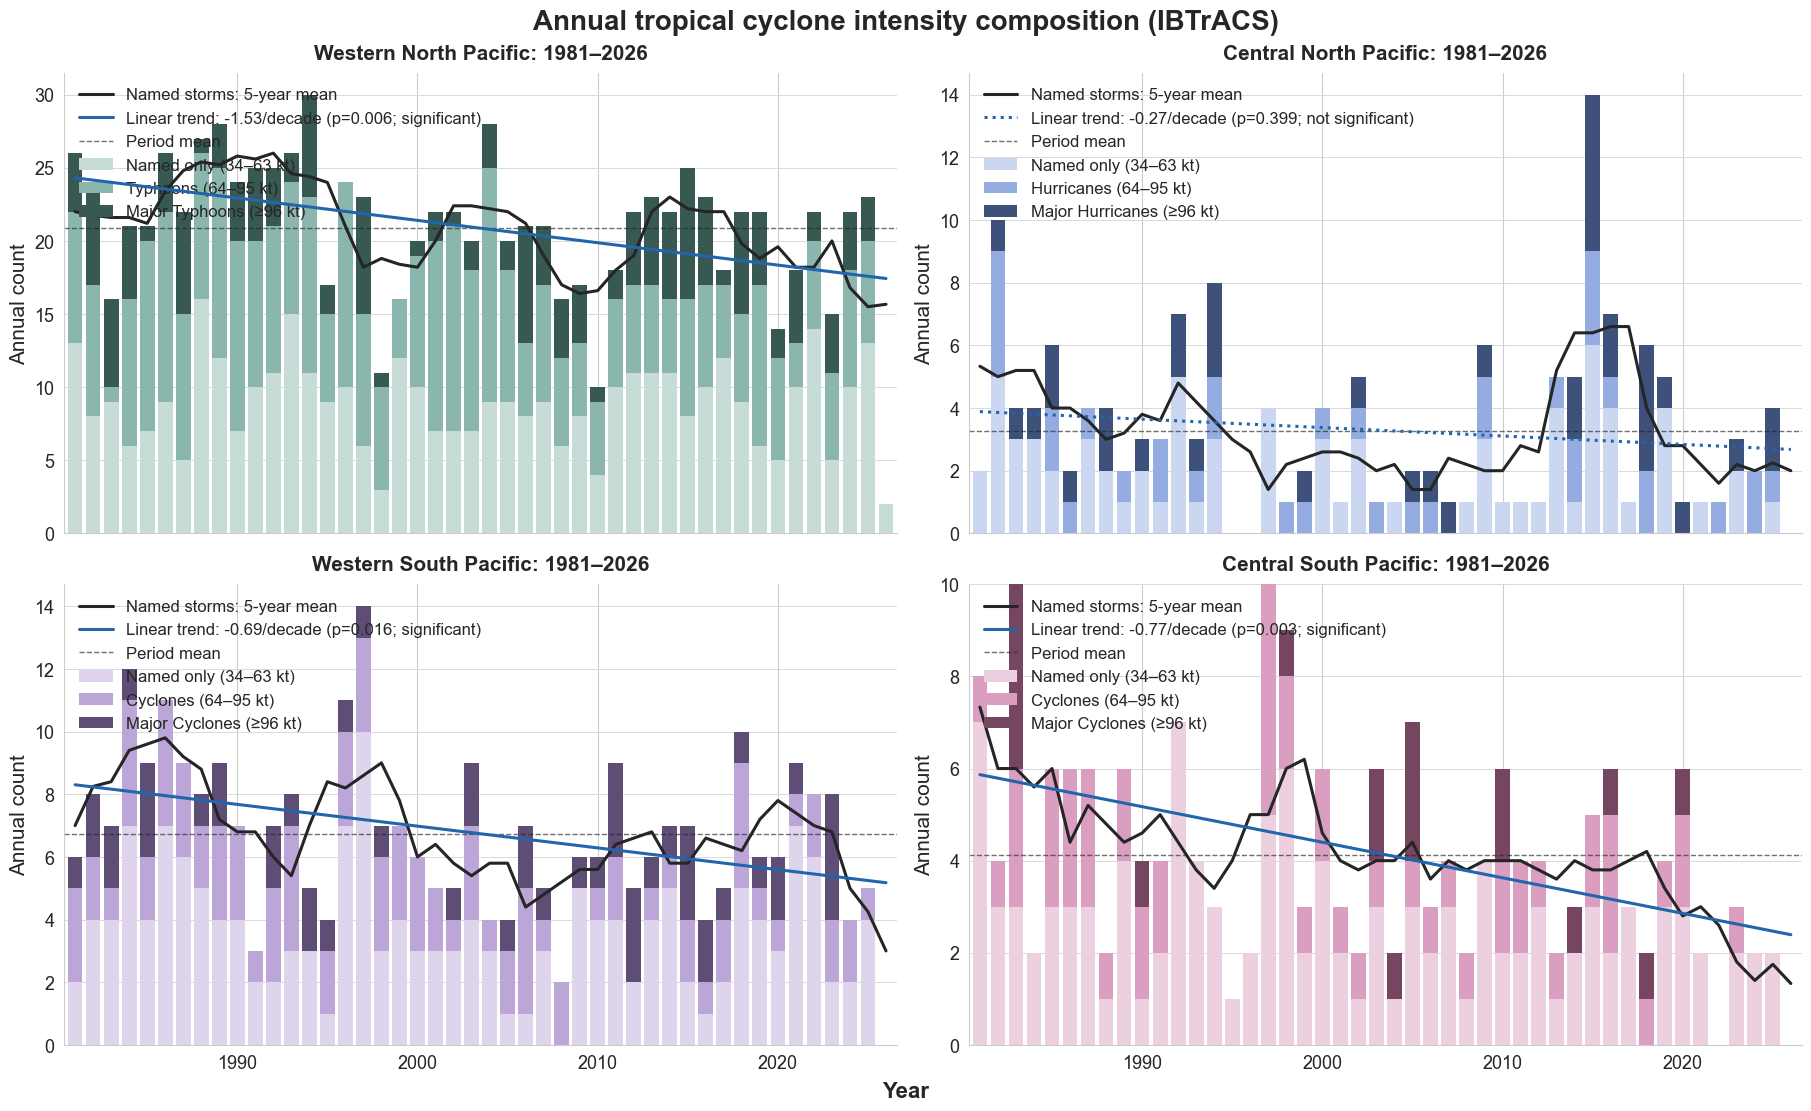

In [10]:
fig, axes = plot_regional_intensity_counts(
    regional_metrics, REGIONS, START_YEAR, END_YEAR, REGION_COLORS
)
fig.savefig(
    maps_dir / f"TC_regional_intensity_composition_{region_key}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## Regional activity charts over the Pacific map

The four inset charts use the same mutually exclusive intensity classes as the stacked-bar figure. The blue trend is solid when significant at 95% and dotted otherwise.

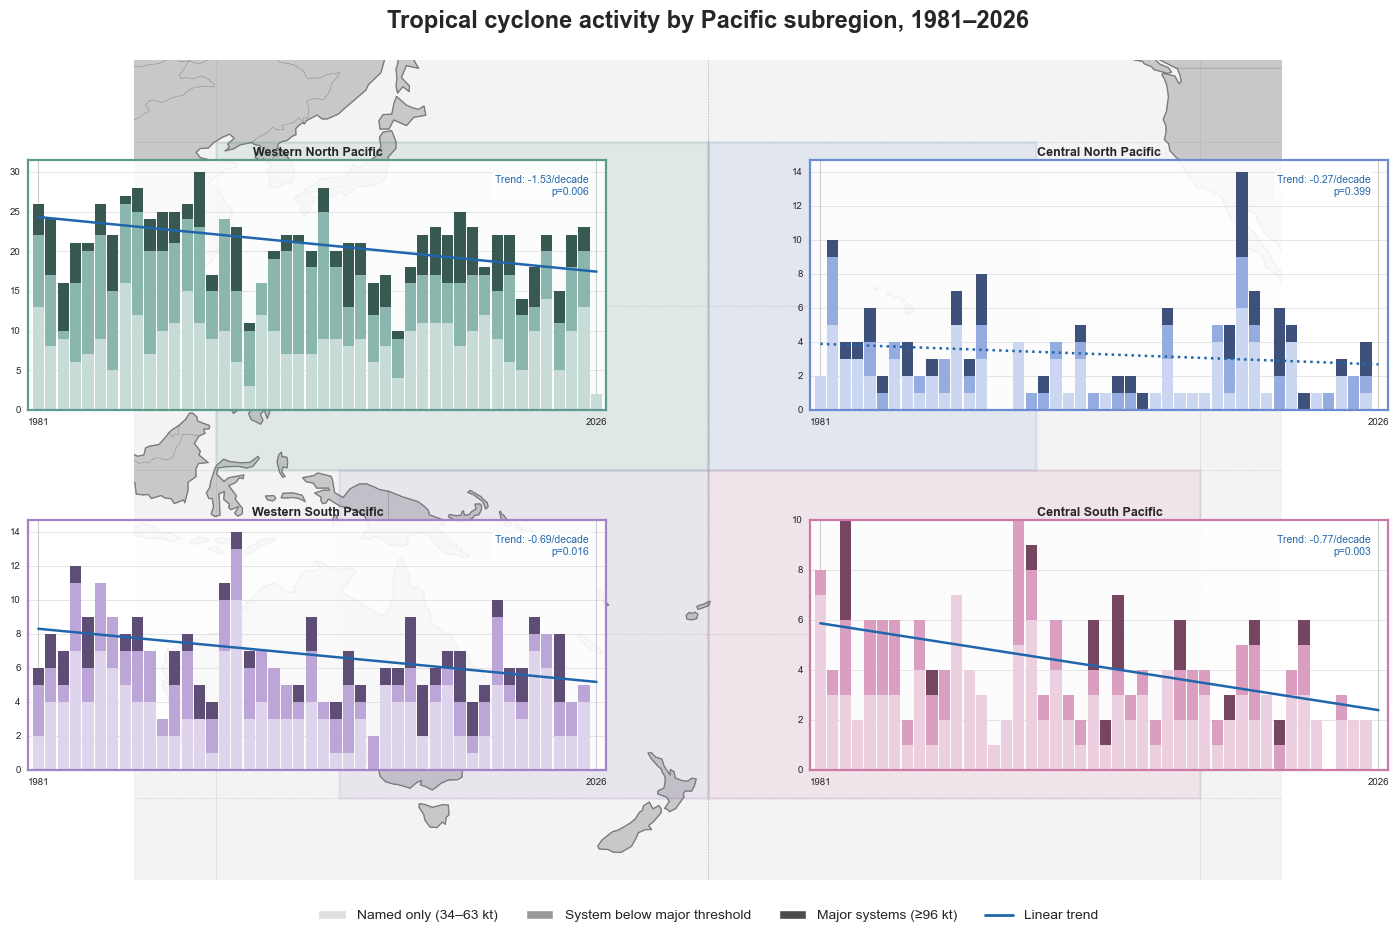

In [11]:
# Figure coordinates mirror the west/east and north/south map boxes.
INSET_POSITIONS = {
    "Western North Pacific": [0.10, 0.56, 0.34, 0.25],
    "Central North Pacific": [0.56, 0.56, 0.34, 0.25],
    "Western South Pacific": [0.10, 0.20, 0.34, 0.25],
    "Central South Pacific": [0.56, 0.20, 0.34, 0.25],
}

fig, map_ax, inset_axes = plot_regional_map_dashboard(
    regional_metrics, REGIONS, START_YEAR, END_YEAR, REGION_COLORS,
    INSET_POSITIONS,
)
fig.savefig(
    maps_dir / f"TC_regional_map_dashboard_{region_key}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## Accumulated Cyclone Energy (ACE)

Annual ACE combines cyclone intensity and duration. Each storm's complete-track ACE is assigned exclusively to its genesis subregion and genesis year. It is calculated as $10^{-4}\sum v^2$ using WMO winds of at least 34 kt at the 00, 06, 12 and 18 UTC synoptic times. Because this uses the IBTrACS WMO wind field, it should be treated as an internally consistent regional ACE indicator rather than mixed directly with agency-specific ACE products based on different wind averaging periods.

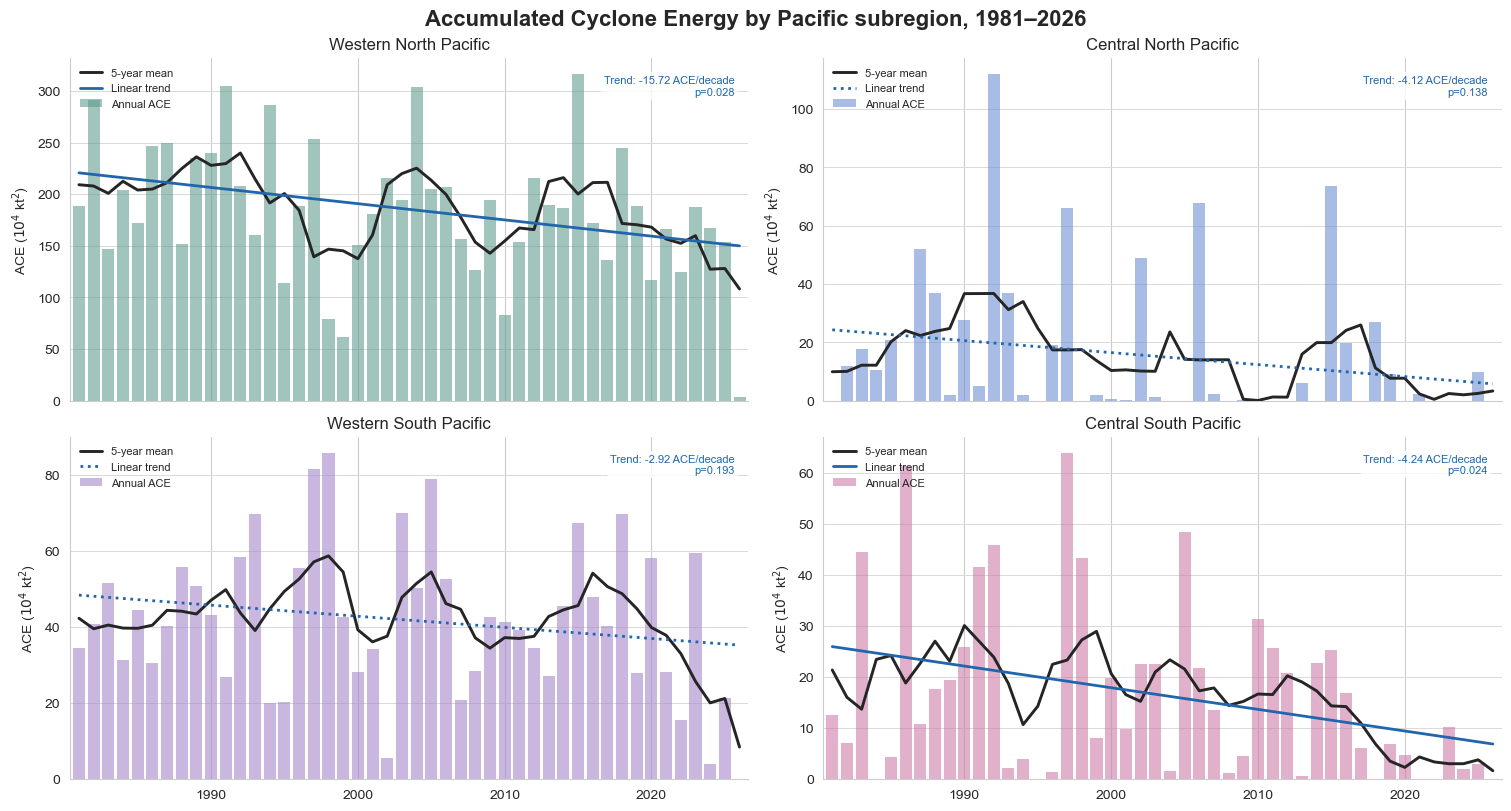

In [12]:
fig, axes = plot_regional_ace(
    regional_metrics, REGION_COLORS, START_YEAR, END_YEAR
)
fig.savefig(
    maps_dir / f"TC_regional_ace_{region_key}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## Optional export

In [13]:
export_tables = False
if export_tables:
    output_dir = Path("../../../../outputs/tables/regional_tropical_cyclones")
    output_dir.mkdir(parents=True, exist_ok=True)
    for name, metrics in regional_metrics.items():
        slug = name.lower().replace(" ", "_")
        metrics.to_csv(output_dir / f"{slug}_{START_YEAR}_{END_YEAR}.csv")